In [1]:
import os
import warnings; warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120})
torch.manual_seed(42); np.random.seed(42)

DATA_PATH = os.environ.get(
    "MONETARY_DATA_PATH", os.path.join("..", "data", "Monetary_transmission_data_III.xlsx")
)
FEATURES   = ["CPI", "EXR", "M2b", "RSV", "BRNT"]
TARGETS    = ["CPI", "EXR"]
TARGET_IDX = [FEATURES.index(t) for t in TARGETS]

SEQ_LEN  = 12     # lookback taps (monthly), same as 04_tdnn.ipynb
EPOCHS   = 200
BATCH_SIZE = 16
LR       = 1e-3
PATIENCE = 25
DEVICE   = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 4 structural-break sub-periods + full dataset — identical partition to every
# other notebook in this project.
WINDOWS = {
    "W1 (2003–2008)": (None,      "2008-05"),
    "W2 (2008–2016)": ("2008-06", "2016-09"),
    "W3 (2016–2022)": ("2016-10", "2022-02"),
    "W4 (2022–end)":  ("2022-03", None),
    "W5 (Full)":      (None,      None),
}

In [2]:
def load_data(path: str) -> pd.DataFrame:
    """Load raw Excel data and enforce a sorted monthly DatetimeIndex."""
    df = pd.read_excel(path, parse_dates=["DATE"])
    return df.sort_values("DATE").set_index("DATE")[FEATURES]


df_full = load_data(DATA_PATH)
print(f"Range : {df_full.index[0].date()} → {df_full.index[-1].date()}  |  {len(df_full)} months")

Range : 2003-01-01 → 2025-10-01  |  274 months


In [3]:
def make_sequences(arr: np.ndarray):
    """
    Slide a fixed SEQ_LEN window over arr.
    X : (n_samples, SEQ_LEN, n_features)
    y : (n_samples, n_targets) — one-step-ahead label
    """
    X = np.stack([arr[i : i + SEQ_LEN] for i in range(len(arr) - SEQ_LEN)])
    y = arr[SEQ_LEN:, TARGET_IDX]
    return X.astype(np.float32), y.astype(np.float32)


def prepare_window(df_win: pd.DataFrame, test_ratio: float = 0.2):
    """
    Fit scaler on train partition only, create sequences, return device tensors.
    Returns: X_tr, y_tr, X_te, y_te, scaler, test_dates
    """
    n     = len(df_win)
    split = max(int(n * (1 - test_ratio)), SEQ_LEN + 2)

    scaler = StandardScaler().fit(df_win.values[:split])
    scaled = np.vstack([
        scaler.transform(df_win.values[:split]),
        scaler.transform(df_win.values[split:]),
    ])
    X, y = make_sequences(scaled)
    n_tr = split - SEQ_LEN
    test_dates = df_win.index[SEQ_LEN + n_tr:]

    def _t(a): return torch.tensor(a, device=DEVICE)
    return _t(X[:n_tr]), _t(y[:n_tr]), _t(X[n_tr:]), _t(y[n_tr:]), scaler, test_dates


In [4]:
class _TDNNBlock(nn.Module):
    """Single TDNN layer: dilated Conv1D → BatchNorm → ReLU → Dropout."""

    def __init__(self, in_ch: int, out_ch: int, kernel: int, dilation: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel,
                      dilation=dilation,
                      padding=dilation * (kernel - 1) // 2),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(),
            nn.Dropout(0.2),
        )

    def forward(self, x): return self.net(x)


class TDNNLSTM(nn.Module):
    """
    Dilated Conv1D encoder feeding an LSTM head.

    Two TDNN blocks (dilations 1, 2) extract local multi-scale features frame-by-frame
    without collapsing the time axis (unlike 04_tdnn.ipynb's AdaptiveAvgPool); the LSTM
    then integrates those features sequentially and its final hidden state is mapped to
    the forecast.

    Input  : (batch, T, n_features)
    Output : (batch, n_targets)
    """

    def __init__(self, n_feat: int, n_out: int, conv_h: int = 32, lstm_h: int = 64, dropout: float = 0.2):
        super().__init__()
        self.encoder = nn.Sequential(
            _TDNNBlock(n_feat, conv_h, 3, 1),
            _TDNNBlock(conv_h, conv_h, 3, 2),
        )
        self.lstm = nn.LSTM(conv_h, lstm_h, num_layers=1, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Linear(lstm_h, n_out)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # (B, T, F) -> (B, F, T) for Conv1d, then back to (B, T, conv_h) for the LSTM.
        z = self.encoder(x.permute(0, 2, 1)).permute(0, 2, 1)
        _, (h_n, _) = self.lstm(z)
        return self.head(self.dropout(h_n[-1]))


In [5]:
def _train_epoch(model, loader, opt, crit) -> float:
    model.train()
    total = 0.0
    for xb, yb in loader:
        opt.zero_grad()
        loss = crit(model(xb), yb)
        loss.backward()
        opt.step()
        total += loss.item() * len(xb)
    return total / len(loader.dataset)


@torch.no_grad()
def _val_loss(model, X, y, crit) -> float:
    model.eval()
    return crit(model(X), y).item()


def fit(model, X_tr, y_tr, X_val, y_val) -> dict:
    """Adam + ReduceLROnPlateau + early stopping; restores best-val weights."""
    loader = DataLoader(TensorDataset(X_tr, y_tr), BATCH_SIZE, shuffle=True)
    opt    = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    crit   = nn.MSELoss()
    sched  = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=10, factor=0.5)

    best_val, no_imp, best_w = np.inf, 0, None
    hist = {"train": [], "val": []}

    for _ in range(EPOCHS):
        tr  = _train_epoch(model, loader, opt, crit)
        val = _val_loss(model, X_val, y_val, crit)
        sched.step(val)
        hist["train"].append(tr)
        hist["val"].append(val)

        if val < best_val:
            best_val, no_imp = val, 0
            best_w = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            no_imp += 1
            if no_imp >= PATIENCE:
                break

    model.load_state_dict({k: v.to(DEVICE) for k, v in best_w.items()})
    return hist

In [6]:
def inv_scale(scaler: StandardScaler, arr: np.ndarray) -> np.ndarray:
    """Inverse-transform target columns only; non-targets padded with zeros."""
    dummy = np.zeros((len(arr), len(FEATURES)), dtype=np.float32)
    dummy[:, TARGET_IDX] = arr
    return scaler.inverse_transform(dummy)[:, TARGET_IDX]


@torch.no_grad()
def get_predictions(model, X) -> np.ndarray:
    model.eval()
    return model(X).cpu().numpy()


def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> pd.DataFrame:
    return pd.DataFrame(
        {
            "RMSE": [np.sqrt(mean_squared_error(y_true[:, i], y_pred[:, i])) for i in range(len(TARGETS))],
            "MAE":  [mean_absolute_error(y_true[:, i], y_pred[:, i])         for i in range(len(TARGETS))],
            "R²":   [r2_score(y_true[:, i], y_pred[:, i])                    for i in range(len(TARGETS))],
        },
        index=TARGETS,
    )


In [7]:
results = {}

for name, (start, end) in WINDOWS.items():
    df_win = df_full.loc[slice(start, end)]

    if len(df_win) < SEQ_LEN + 10:
        print(f"[{name}] skipped — {len(df_win)} obs < minimum required")
        continue

    X_tr, y_tr, X_te, y_te, scaler, test_dates = prepare_window(df_win)
    model   = TDNNLSTM(len(FEATURES), len(TARGETS)).to(DEVICE)
    history = fit(model, X_tr, y_tr, X_te, y_te)

    y_pred_s = get_predictions(model, X_te)
    y_true   = inv_scale(scaler, y_te.cpu().numpy())
    y_pred   = inv_scale(scaler, y_pred_s)
    mets     = compute_metrics(y_true, y_pred)

    results[name] = dict(
        history=history, y_true=y_true, y_pred=y_pred,
        metrics=mets, model=model, scaler=scaler, df_win=df_win, test_dates=test_dates,
    )
    print(f"\n{'─' * 54}\n  {name}  "
          f"({len(df_win)} obs | train={len(y_tr)} | test={len(y_te)})\n{'─' * 54}")
    display(mets.round(4))



──────────────────────────────────────────────────────
  W1 (2003–2008)  (65 obs | train=40 | test=13)
──────────────────────────────────────────────────────


,RMSE,MAE,R²
CPI,11.1490,8.9873,-2.3514
EXR,1.7565,1.5547,0.2405



──────────────────────────────────────────────────────
  W2 (2008–2016)  (100 obs | train=68 | test=20)
──────────────────────────────────────────────────────


,RMSE,MAE,R²
CPI,3.0836,2.2682,0.0291
EXR,7.4815,6.0509,-1.0573



──────────────────────────────────────────────────────
  W3 (2016–2022)  (65 obs | train=40 | test=13)
──────────────────────────────────────────────────────


,RMSE,MAE,R²
CPI,19.4094,15.1602,-2.5117
EXR,11.0827,10.7474,-22.9173



──────────────────────────────────────────────────────
  W4 (2022–end)  (44 obs | train=23 | test=9)
──────────────────────────────────────────────────────


,RMSE,MAE,R²
CPI,2.3170,1.7898,-1.0003
EXR,9.3274,8.5722,-15.9794



──────────────────────────────────────────────────────
  W5 (Full)  (274 obs | train=207 | test=55)
──────────────────────────────────────────────────────


,RMSE,MAE,R²
CPI,115.7290,105.0917,-4.3568
EXR,110.9694,98.0421,-3.4100


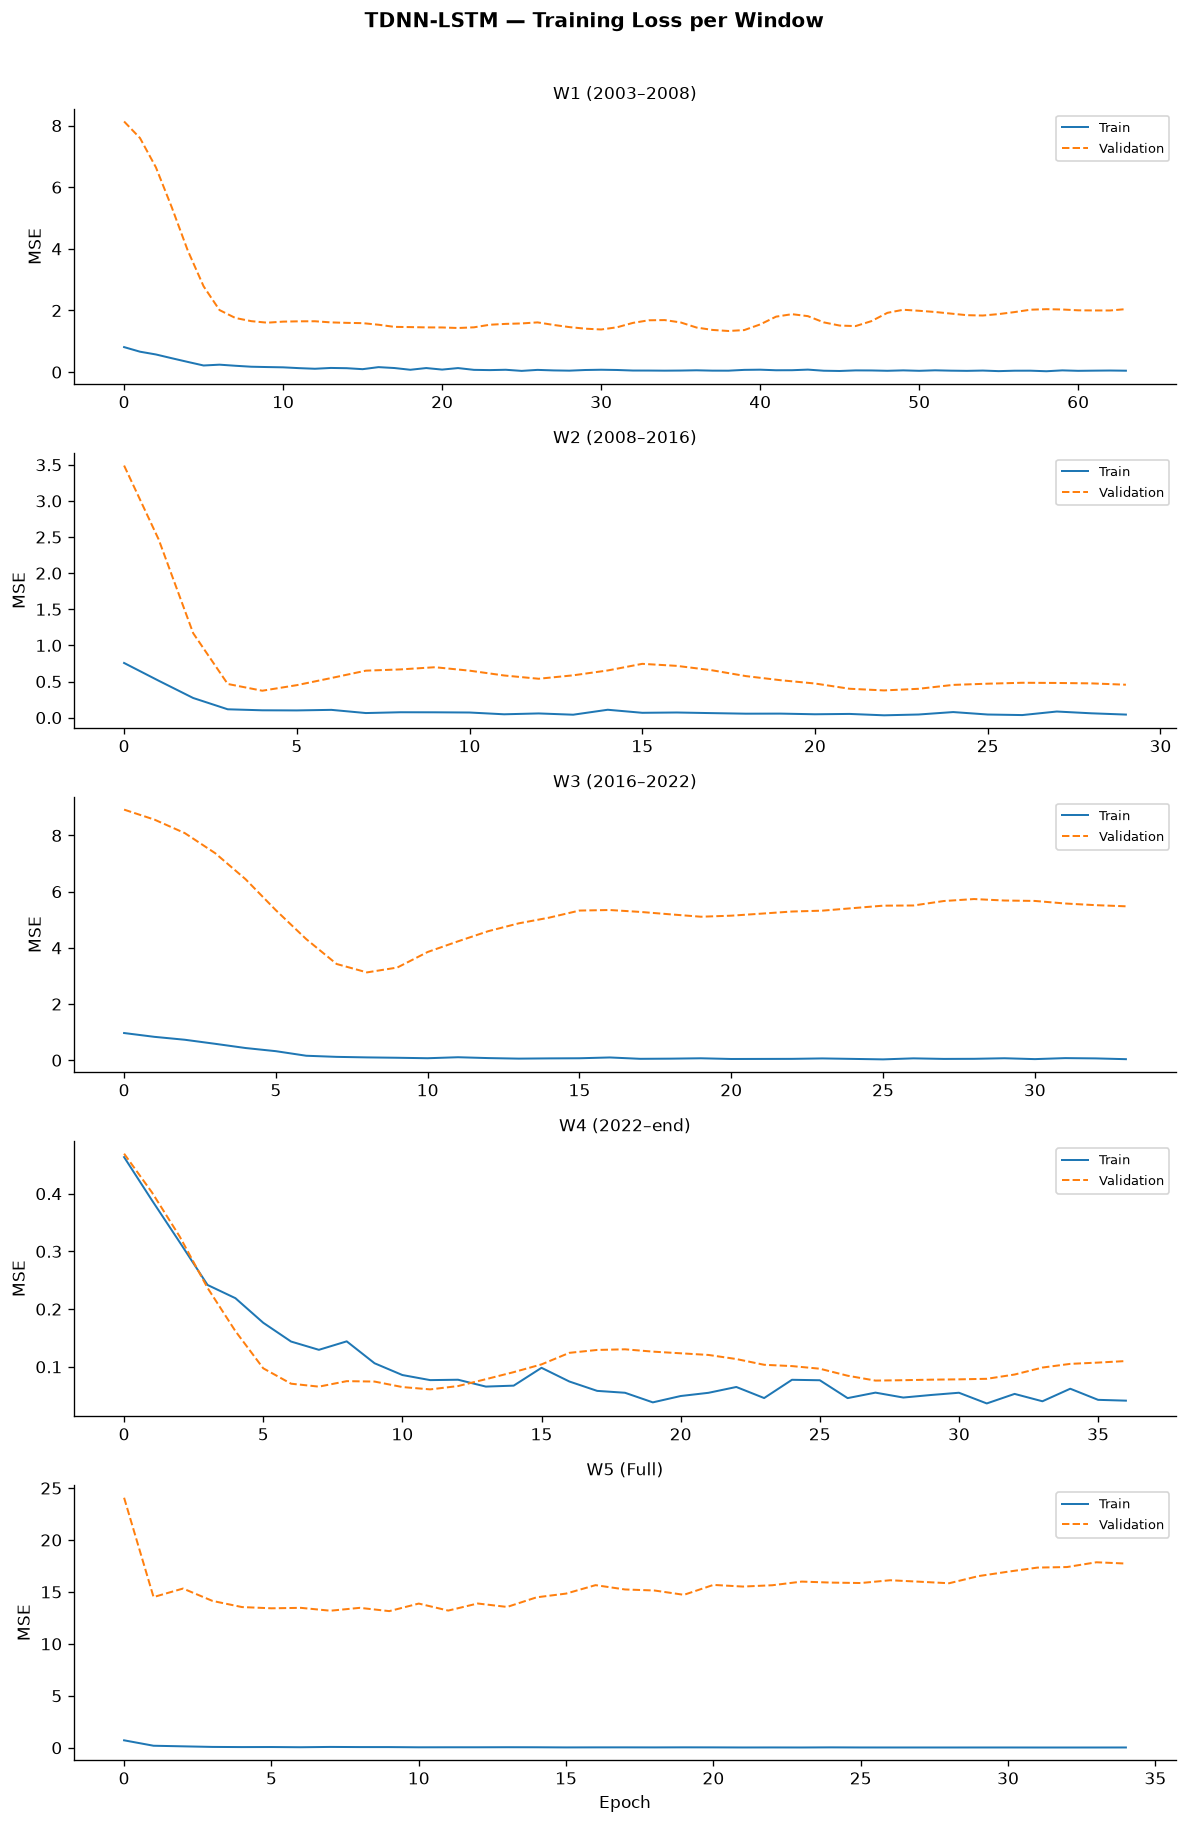

In [8]:
n    = len(results)
fig, axes = plt.subplots(n, 1, figsize=(10, 3 * n))
axes = np.atleast_1d(axes)

for ax, (name, res) in zip(axes, results.items()):
    h = res["history"]
    ax.plot(h["train"], lw=1.2, label="Train")
    ax.plot(h["val"],   lw=1.2, ls="--", label="Validation")
    ax.set_title(name, fontsize=10)
    ax.set_ylabel("MSE")
    ax.legend(fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)

axes[-1].set_xlabel("Epoch")
plt.suptitle("TDNN-LSTM — Training Loss per Window", fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


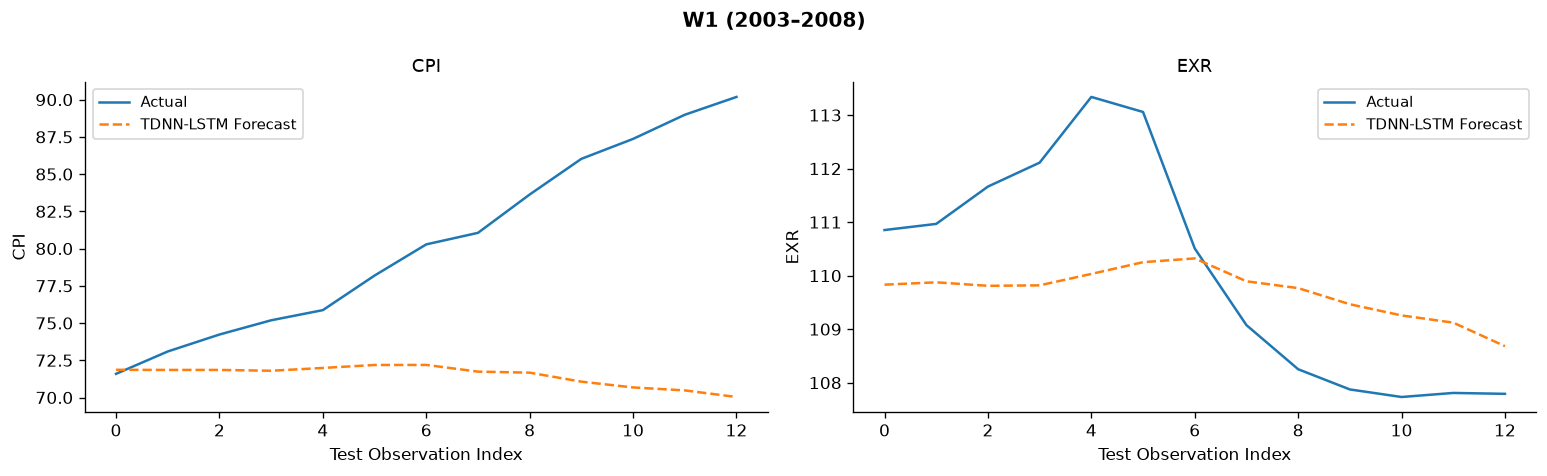

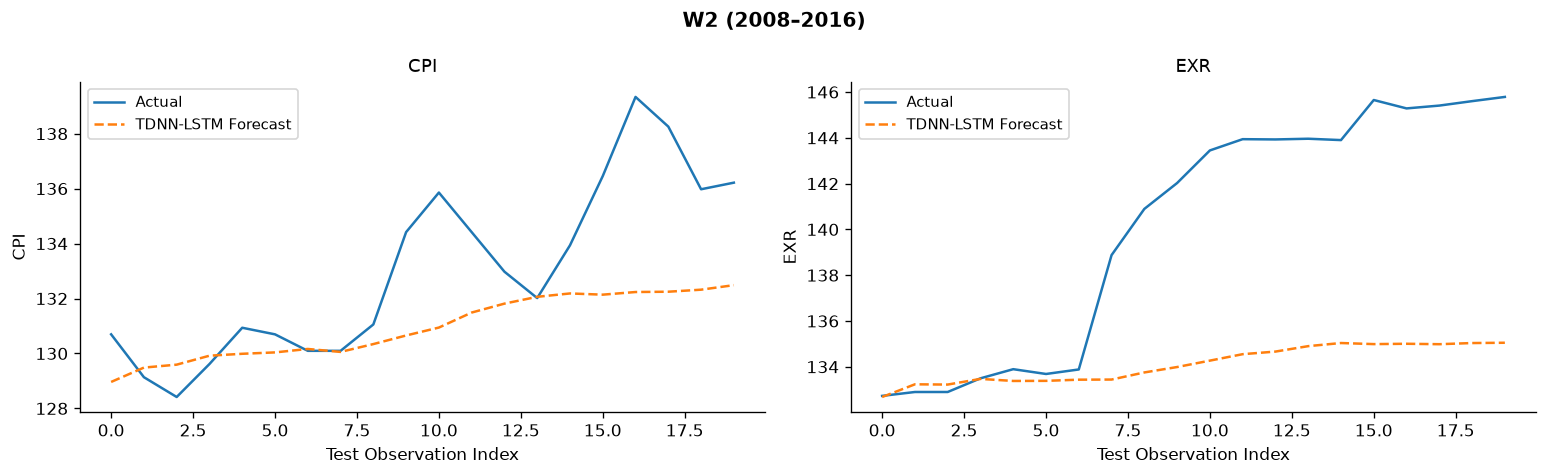

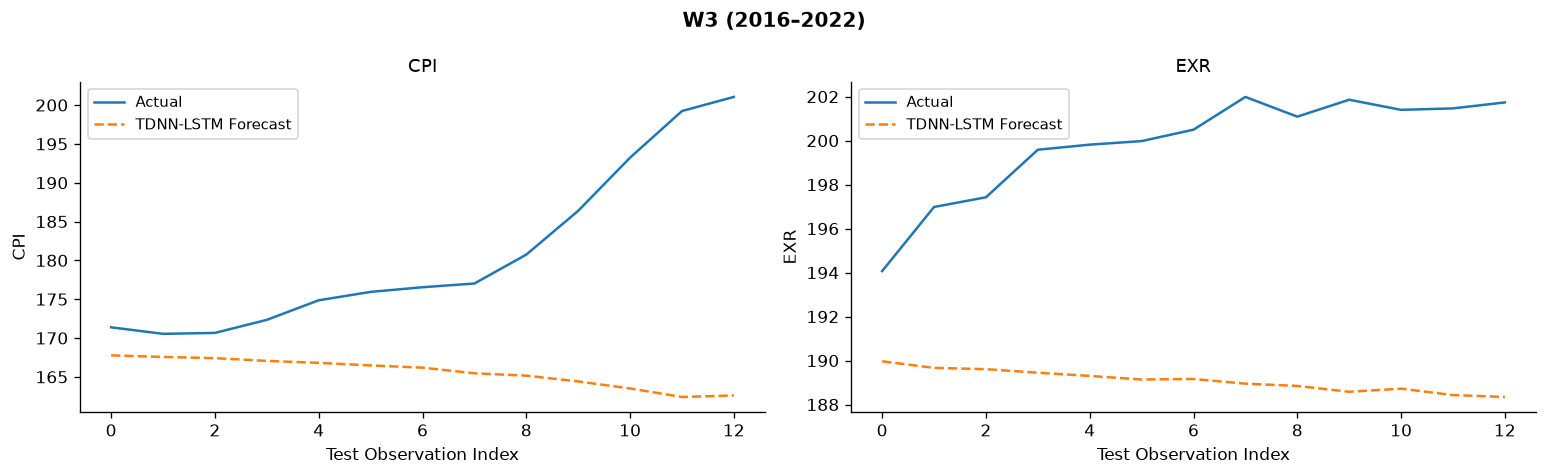

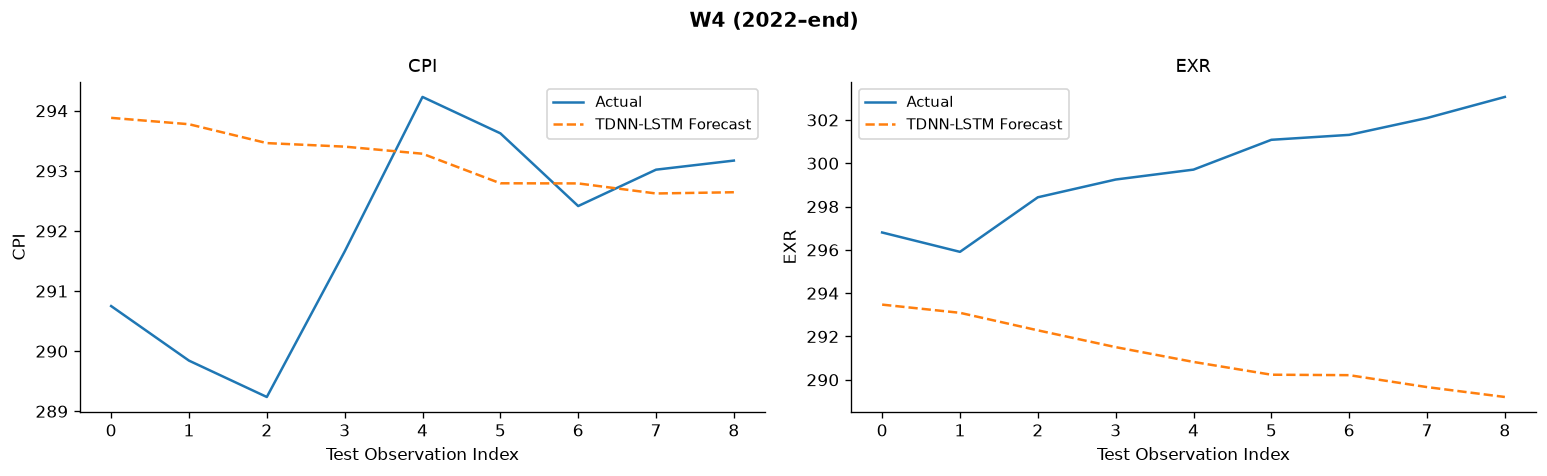

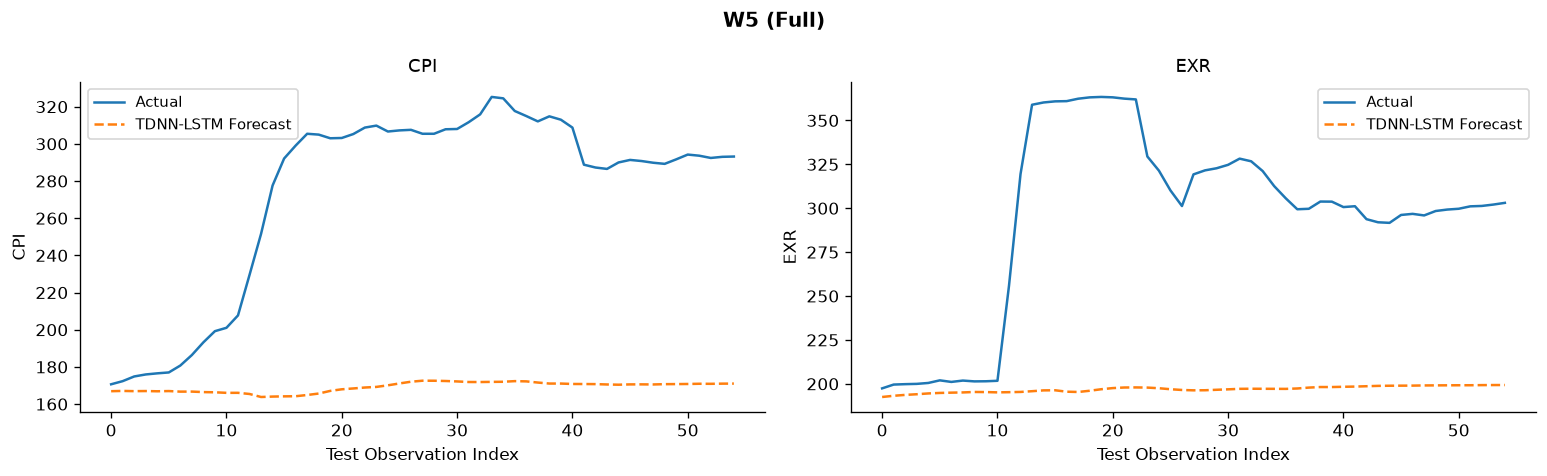

In [9]:
for name, res in results.items():
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for i, (ax, tgt) in enumerate(zip(axes, TARGETS)):
        ax.plot(res["y_true"][:, i], lw=1.5, label="Actual")
        ax.plot(res["y_pred"][:, i], lw=1.5, ls="--", label="TDNN-LSTM Forecast")
        ax.set_title(tgt, fontsize=11)
        ax.set_xlabel("Test Observation Index")
        ax.set_ylabel(tgt)
        ax.legend(fontsize=9)
        ax.spines[["top", "right"]].set_visible(False)
    plt.suptitle(name, fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

In [10]:
summary = pd.concat(
    {name: res["metrics"] for name, res in results.items()},
    names=["Window", "Target"],
)
print("=== TDNN-LSTM Performance Summary ===")
display(summary.round(4))

=== TDNN-LSTM Performance Summary ===


RMSE       MAE       R²
Window         Target                             
W1 (2003–2008) CPI      11.1490    8.9873  -2.3514
               EXR       1.7565    1.5547   0.2405
W2 (2008–2016) CPI       3.0836    2.2682   0.0291
               EXR       7.4815    6.0509  -1.0573
W3 (2016–2022) CPI      19.4094   15.1602  -2.5117
               EXR      11.0827   10.7474 -22.9173
W4 (2022–end)  CPI       2.3170    1.7898  -1.0003
               EXR       9.3274    8.5722 -15.9794
W5 (Full)      CPI     115.7290  105.0917  -4.3568
               EXR     110.9694   98.0421  -3.4100

In [11]:
os.makedirs("../results", exist_ok=True)
# Standardized long-format export consumed by the model-comparison pipeline.
export_rows = [
    {"window": name.split()[0], "target": tgt, "RMSE": res["metrics"].loc[tgt, "RMSE"], "MAE": res["metrics"].loc[tgt, "MAE"]}
    for name, res in results.items() for tgt in TARGETS
]
pd.DataFrame(export_rows).to_csv("../results/metrics_hybrid_neural.csv", index=False)

# Raw test-set predictions, for consistency with the other model notebooks.
pred_rows = [
    {"window": name.split()[0], "target": tgt, "date": date,
     "actual": res["y_true"][i, j], "predicted": res["y_pred"][i, j]}
    for name, res in results.items()
    for i, date in enumerate(res["test_dates"])
    for j, tgt in enumerate(TARGETS)
]
pd.DataFrame(pred_rows).to_csv("../results/predictions_hybrid_neural.csv", index=False)